### Routing
- Dynamic workflow path selection based on contigent factors
- Conditional logic is evaluted by an agent to route the workflow towards different paths

In [17]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI

load_dotenv()

True

In [18]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)

In [19]:
class AgentState(TypedDict):
    input_text: str
    route_path: str
    response: str

In [20]:
#Node 1: Route path selection
def route_path_selection(input: AgentState) -> AgentState:

    system_msg = f"""
    You are an expert agent that routes user requests to the appropriate specialist handler to process it.
    - If the request is about booking travel or hoter, output "booker"
    - For all other request, output "general".
    - If the request is unclear or ambiguous, output "followup".
    Output only one word from "booker", "general", or "followup".
    """
    user_msg = f"""
    User request: {input['input_text']}
    """

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]

    response = model.invoke(messages)
    input["route_path"] = response.content.strip().lower()
    print(f"Route path selected: {input['route_path']}")
    return input


In [21]:
#Node 2_1: Booker handler
def booker_handler(input: AgentState) -> AgentState:

    system_msg = f"""
    You are an expert agent in hadling travel and hotel bookings.
    Provide a 2 sentence response to the user request.
    """
    user_msg = f"""
    User request: {input['input_text']}
    """

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]

    response = model.invoke(messages)
    input["response"] = response.content.strip().lower()
    print(f"Booker response generated: {input['response']}")
    return input


In [22]:
#Node 2_2: General handler
def general_handler(input: AgentState) -> AgentState:

    system_msg = f"""
    You are an expert agent in handling general inquiries.
    Provide a 2 sentence response to the user request.
    """
    user_msg = f"""
    User request: {input['input_text']}
    """

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]

    response = model.invoke(messages)
    input["response"] = response.content.strip().lower()
    print(f"General response generated: {input['response']}")
    return input


In [23]:
#Node 2_3: Followup handler
def followup_handler(input: AgentState) -> AgentState:

    system_msg = f"""
    You are an expert agent in handling unclear or ambiguous user requests.
    Ask a clarifying question to the user.
    """
    user_msg = f"""
    User request: {input['input_text']}
    """

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]

    response = model.invoke(messages)
    input["response"] = response.content.strip().lower()
    print(f"Booker response generated: {input['response']}")
    return input


In [24]:
from typing import Literal


def router(input: AgentState) -> Literal[ "booker", "general", "followup"]:
    route = input["route_path"]
    if route == "booker":
        return "booker"
    elif route == "general":
        return "general"
    else:
        return "followup"

In [25]:
workflow = StateGraph(AgentState)

workflow.add_node("router", route_path_selection)
workflow.add_node("booker", booker_handler)
workflow.add_node("general", general_handler)
workflow.add_node("followup", followup_handler)

workflow.set_entry_point("router")
workflow.add_conditional_edges(
    "router",
    router,
    {
        "booker": "booker",
        "general": "general",
        "followup": "followup",
    },
)
workflow.add_edge("booker", END)
workflow.add_edge("general", END)
workflow.add_edge("followup", END)

graph = workflow.compile()
                               
                               

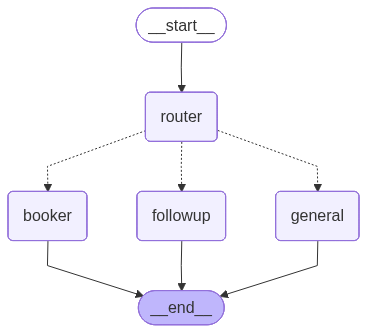

In [26]:
from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod

graph_image = graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.API
)

display(Image(graph_image))

In [27]:
# Test booker agent
print("---- Testing Booker Agent ----")
result = graph.invoke({
    "input_text": "I want to book a flight to Paris"
})
print("Result:", result["response"])

---- Testing Booker Agent ----
Route path selected: booker
Booker response generated: sure! please provide your departure city, preferred travel dates, and any specific airline preferences you may have, and i'll assist you with the booking.
Result: sure! please provide your departure city, preferred travel dates, and any specific airline preferences you may have, and i'll assist you with the booking.


In [28]:
# Test general agent
print("---- Testing General Agent ----")
result = graph.invoke({
    "input_text": "What is the capital of France?"
})
print("Result:", result["response"])

---- Testing General Agent ----
Route path selected: general
General response generated: the capital of france is paris. it is known for its art, fashion, and historical landmarks.
Result: the capital of france is paris. it is known for its art, fashion, and historical landmarks.


In [29]:
# Test followup agent
print("---- Testing Followup Agent ----")
result = graph.invoke({
    "input_text": "I don't know what to ask"
})
print("Result:", result["response"])

---- Testing Followup Agent ----
Route path selected: followup
Booker response generated: what topic or area are you interested in exploring or learning more about?
Result: what topic or area are you interested in exploring or learning more about?
